# 1. Torch utilities

In [1]:
import os 
import torch
import torch.distributions as tdist
from torch.utils.dlpack import to_dlpack
from torch.utils.dlpack import from_dlpack
rnorm = tdist.Normal(torch.tensor([0.]), torch.tensor([1]))
from torch.autograd import Function
import numpy as np
from sksparse.cholmod import cholesky
import scipy.sparse as scsp
from math import sqrt 
from torch_sparse.tensor import SparseTensor
from torch_sparse.matmul import matmul as matmul2
import cupy
from cupyx.scipy.sparse.linalg import spsolve as cupy_spsolve
from cupyx.scipy.sparse import csc_matrix as cupy_sp_csc_matrix
import matplotlib
import matplotlib.pyplot as plt
from IPython import display
from IPython.display import Image
import imageio

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class Scipy_SolveCholesky(Function):

# Cholesky decomposition of sparse matrices

    @staticmethod
    def forward(self, torch_sparsematrix, dt, perm=False):
        # cast torch_sparsematrix to scipy sparse csc matrix 
        sp_sparsematrix = scsp.csc_matrix((torch_sparsematrix.detach().cpu().coalesce().values(),
                                           torch_sparsematrix.detach().cpu().coalesce().indices()),
                                          shape=(torch_sparsematrix.shape[0],torch_sparsematrix.shape[0]))

        A = scsp.identity(sp_sparsematrix.shape[0])+\
            (dt* sp_sparsematrix) 
        
        # Cholesky decomposition with permutation A=P'LL'P
        if perm==True:
            AspChol = cholesky(A)
            # save input requires for backward (A here from Ax=b) and
            self.save_for_backward( torch.tensor(AspChol.P()), torch.tensor(AspChol.L()) )
        else:
            # Cholesky decomposition without permutation A=L'L
            AspChol = cholesky(A,ordering_method="natural")
            # save input requires for backward (A here from Ax=b) and
            Lcoo = AspChol.L().tocoo()
            L = torch.sparse.FloatTensor(torch.LongTensor([Lcoo.row.tolist(), Lcoo.col.tolist()]),
                                                torch.FloatTensor(Lcoo.data))
            self.save_for_backward(L)

        return torch.as_tensor(L, dtype=torch_sparsematrix.dtype)
    
def sparse_eye(size, val = torch.tensor(1.0)):
    """
    Returns the identity matrix as a sparse matrix
    """
    indices = torch.arange(0, size).long().unsqueeze(0).expand(2, size)
    if len(val.size())==0:
        values = (val.expand(size))
    else:
        values = val.to(device)
    cls = getattr(torch.sparse, values.type().split(".")[-1])
    return cls(indices, values, torch.Size([size, size]))

def sparse_repeat(size,n1,n2):
    """
    Returns a sparse zero-filled tensor repeating 
    a 2D size*size sparse zero-filled tensor
    n1 times along dim1 and n2 times along n2
    """
    return torch.sparse.FloatTensor(size*n1,size*n2)

def spspmm(A,B):
    """Matrix product of two sparse tensors. Both input sparse matrices need to
    be coalesced (use the :obj:`coalesced` attribute to force).
    Args:
        indexA (:class:`LongTensor`): The index tensor of first sparse matrix.
        valueA (:class:`Tensor`): The value tensor of first sparse matrix.
        indexB (:class:`LongTensor`): The index tensor of second sparse matrix.
        valueB (:class:`Tensor`): The value tensor of second sparse matrix.
        m (int): The first dimension of first corresponding dense matrix.
        k (int): The second dimension of first corresponding dense matrix and
            first dimension of second corresponding dense matrix.
        n (int): The second dimension of second corresponding dense matrix.
        coalesced (bool, optional): If set to :obj:`True`, will coalesce both
            input sparse matrices. (default: :obj:`False`)
    :rtype: (:class:`LongTensor`, :class:`Tensor`)
    """

    indexA = A.detach().cpu().coalesce().indices()
    valueA = A.detach().cpu().coalesce().values()
    indexB = B.detach().cpu().coalesce().indices()
    valueB = B.detach().cpu().coalesce().values()
    m = A.size()[0]
    k = A.size()[1]
    n = B.size()[1]

    coalesced =True

    A2 = SparseTensor(row=indexA[0], col=indexA[1], value=valueA,
                     sparse_sizes=(m, k), is_sorted=not coalesced)
    B2 = SparseTensor(row=indexB[0], col=indexB[1], value=valueB,
                     sparse_sizes=(k, n), is_sorted=not coalesced)
    
    C = matmul2(A2, B2)
    row, col, value = C.coo()
    indexC = torch.stack([row, col], dim=0)
    valueC = value

    return torch.sparse.FloatTensor(indexC.long(), valueC, torch.Size([m,n]))

def pow_diff_operator(A,pow):
    B = A
    if pow>1:
      for _ in range(pow-1):
        B = spspmm(B,A)  
    return B

# 2. SPDE-based spatio-temporal simulation

Let now consider the spatio-temporal extension to perform non-conditional simulations of a
random field $\mathbf{x}$ solution of the spatio-temporal SPDE:
\begin{eqnarray}
\label{isotropic_SPDE_st}
\frac{\partial{\mathbf{X}}}{\partial{t}}+(\kappa^2(\mathbf{s},t)-\Delta)^{\alpha/2} \mathbf{X}(\mathbf{s},t)=\tau \mathbf{Z}(\mathbf{s},t)
\end{eqnarray}

To ensure more regularity it is also possible to consider the noise process $\mathbf{Z}$ be white in time but with spatial dependence, such as a solution to an isotropic spatial SPDE for instance:
\begin{align*}
& \mathbf{Z}(\mathbf{s},t) = \mathbf{Z}_T(t) \otimes  \mathbf{W}_S(\mathbf{s})
\end{align*}
with
\begin{align}
\label{isotropic_spatial_SPDE}
& (\kappa_S^2 - \Delta)^{\alpha_S/2} \mathbf{W}_S(\mathbf{s}) = \mathbf{Z}_S(\mathbf{s})
\end{align}

This lead to the final model:
\begin{eqnarray}
\label{isotropic_SPDE_st_2}
\frac{\partial{\mathbf{X}}}{\partial{t}}+(\kappa^2(\mathbf{s},t)-\Delta)^{\alpha/2} \mathbf{X}(\mathbf{s},t)=\tau \mathbf{Z}_T(t) \otimes  \mathbf{W}_S(\mathbf{s})
\end{eqnarray}

We use a numerical implicit Euler scheme to discretize the space-time SPDE:
\begin{eqnarray*}
\frac{\mathbf{x}_{t+dt}-\mathbf{x}_{t}}{dt}+\mathbf{B}\mathbf{x}_{t+dt}=\frac{\tau}{\sqrt{dt}} \mathbf{w}_{t+dt}
\end{eqnarray*} 

where

* $\mathbf{x}_{t}$ the state space at time $t$
* $\mathbf{B}$ is still the discrete differential operator $(\kappa^2-\Delta)^{\alpha/2}$ 
* The random vectors $\lbrace \mathbf{w}_t$, $t>0 \rbrace$ are independent realizations of $\mathbf{W}_S$ the solution of a spatial isotropic SPDE

Let now develop the relation between $\mathbf{x}_{t+dt}$ using $\mathbf{x}_{t}$ and $\mathbf{z}_{t+dt}$ :
\begin{align}
\label{implicit_scheme}
& \frac{\mathbf{x}_{t+dt}-\mathbf{x}_{t}}{dt}+\mathbf{B}_{t+dt}\mathbf{x}_{t+dt}&=&\frac{\tau}{\sqrt{dt}} \mathbf{w}_{t+dt} \nonumber \\
& \mathbf{x}_{t+dt}-\mathbf{x}_{t} + dt\mathbf{B}_{t+dt}\mathbf{x}_{t+dt}&=&\tau\sqrt{dt} \mathbf{w}_{t+dt} \nonumber  \\
& (\mathbf{I}+dt\mathbf{B}_{t+dt})\mathbf{x}_{t+dt}&=&\mathbf{x}_{t}+\tau\sqrt{dt}\mathbf{w}_{t+dt} \nonumber  \\
& \mathbf{x}_{t+dt} &=&(\mathbf{I}+dt\mathbf{B}_{t+dt})^{-1}(\mathbf{x}_{t}+\tau\sqrt{dt}\mathbf{w}_{t+dt}) \nonumber  \\
& \mathbf{x}_{t+dt} &=& \mathbf{M}_{t+dt}(\mathbf{x}_{t}+\tau \sqrt{dt} \mathbf{w}_{t+dt}) &
\end{align}

From now on, let denote $\mathbf{M}_{t+dt}=(\mathbf{I}+dt\mathbf{B}_{t+dt})^{-1}$ the matrix operator to emulate the dynamical evolution of state $\mathbf{x}$ from time $t$ to $t+dt$. It will ease the link with formal data assimilation state space formulation.

## 2.1 Global anisotropy

The Laplacian operator $\Delta$ is invariant to translations and
rotations. As a consequence, we will get an isotropic space-time field. Then, let introduce some diffusion process through a local diffusion operator $\mathbf{H}(\mathbf{s},t)$ in the SPDE. In the case of global anisotropy, $\mathbf{H}$ is constant over space and time:

\begin{eqnarray*}
(\kappa^2-\nabla \cdot \mathbf{H}\nabla)^{\frac{\alpha}{2}}\mathbf{X}(\mathbf{s},t)=\tau\mathbf{Z}(\mathbf{s},t)
\end{eqnarray*}

/tmp/ipykernel_2150125/2997379416.py:53: UserWarning: torch.sparse.SparseTensor(indices, values, shape, *, device=) is deprecated.  Please use torch.sparse_coo_tensor(indices, values, shape, dtype=, device=). (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:653.)
  return(torch.sparse.FloatTensor(k[0:2].long(), k[2], torch.Size([nb_nodes,nb_nodes])))


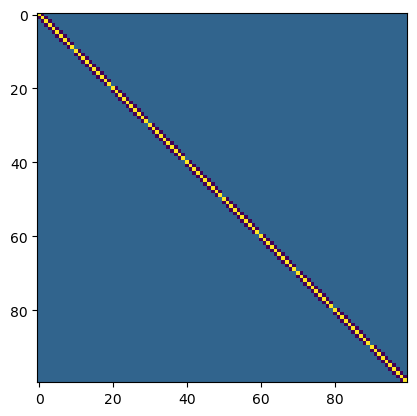

In [2]:
def diff_operator(nx, ny, dx, dy, H, kappa):

    nb_nodes = nx*ny
    H11=H[0,0] ; H12=H[0,1] ; H21=H[1,0] ; H22=H[0,1]  
    
    index = torch.arange(0,nb_nodes)
    ## Right neighbours
    index_sel = torch.where(torch.fmod(index+1,nx) != 0)[0]
    N=len(index_sel)
    index_sel_neighs = torch.index_select(index,0,index_sel)
    k1 = torch.stack((index_sel_neighs.float(), index_sel_neighs.float() + 1, (-1*H11/(dx**2)).repeat_interleave(N) ))
    ## Left neighbours
    index_sel = torch.where(torch.fmod(index+1,nx) != 1)[0]
    N=len(index_sel)
    index_sel_neighs = torch.index_select(index,0,index_sel)
    k2 = torch.stack((index_sel_neighs.float(), index_sel_neighs.float() - 1, (-1*H11/(dx**2)).repeat_interleave(N) ))
    ## Top neighbours
    index_sel = torch.where((index+1) <= (ny-1)*nx )[0]
    N=len(index_sel)
    index_sel_neighs = torch.index_select(index,0,index_sel)
    k3 = torch.stack((index_sel_neighs.float(), index_sel_neighs.float() + nx, (-1*H22/(dx**2)).repeat_interleave(N) ))
    ## Bottom neighbours
    index_sel = torch.where((index+1) >= (nx+1) )[0]
    N=len(index_sel)
    index_sel_neighs = torch.index_select(index,0,index_sel)
    k4 = torch.stack((index_sel_neighs.float(), index_sel_neighs.float() - nx, (-1*H22/(dx**2)).repeat_interleave(N) ))
    ## Top-right neighbours
    index_sel = torch.where( (torch.fmod(index+1,nx) != 0) & ((index+1)<= (ny-1)*nx) )[0]
    N=len(index_sel)
    index_sel_neighs = torch.index_select(index,0,index_sel)
    k5 = torch.stack((index_sel_neighs.float(), index_sel_neighs.float() + nx+1, ((H12+H21)/(4*dx*dy)).repeat_interleave(N) ))
    ## Top-left neighbours
    index_sel = torch.where( (torch.fmod(index+1,nx) != 1) & ((index+1)<= (ny-1)*nx) )[0]
    N=len(index_sel)
    index_sel_neighs = torch.index_select(index,0,index_sel)
    k6 = torch.stack((index_sel_neighs.float(), index_sel_neighs.float() + nx-1, (-1*(H12+H21)/(4*dx*dy)).repeat_interleave(N) ))
    ## Bottom-right neighbours
    index_sel = torch.where( (torch.fmod(index+1,nx) != 0) & ((index+1)>=(nx+1)) )[0]
    N=len(index_sel)
    index_sel_neighs = torch.index_select(index,0,index_sel)
    k7 = torch.stack((index_sel_neighs.float(), index_sel_neighs.float() - nx+1, (-1*(H12+H21)/(4*dx*dy)).repeat_interleave(N) ))
    ## Bottom-left neighbours
    index_sel = torch.where( (torch.fmod(index+1,nx) != 1) & ((index+1)>=(nx+1)) )[0]
    N=len(index_sel)
    index_sel_neighs = torch.index_select(index,0,index_sel)
    k8 = torch.stack((index_sel_neighs.float(), index_sel_neighs.float() - nx-1, ((H12+H21)/(4*dx*dy)).repeat_interleave(N) ))
    ## Central point
    N=len(index)
    k9 = torch.stack((index.float(), index.float(), (kappa**2 + 2*(H11/(dx**2) + H22/(dy**2))).repeat_interleave(N) ))
    ## Stack all neighbours
    k = torch.cat((k1, k2, k3, k4, k5, k6, k7, k8, k9),dim=1)
    ## Create sparseMatrix
    return(torch.sparse.FloatTensor(k[0:2].long(), k[2], torch.Size([nb_nodes,nb_nodes])))

# Example
A = diff_operator(10,10,1,1,H=torch.tensor(np.array([[1,0],[0,1]])),kappa=1/3)
plt.imshow(A.to_dense().numpy())

##  2.2 Parameters of the simulation

In [3]:
# Domain size
resolution=5
nx = int(12.8*resolution)
ny = int(12.8*resolution)
nb_nodes = nx*ny
# x, y and time lag
dx = 1
dy = 1
dt = 1
# kappa
kappa = 1/3
pow = 1
# Simulation total time
tps = 100
n_iter = int(tps/dt)

## 2.3 Cholesky decomposition

In [4]:
A = diff_operator(nx,ny,dx,dy,torch.tensor(np.array([[1,1],[1,1]])),kappa)
B = pow_diff_operator(A,pow)
# Cholesky decomposition of (I+dtB)
L = Scipy_SolveCholesky.apply(B,dt)
Achol = torch.tensor(np.dot(L.to_dense().numpy(),np.transpose(L.to_dense().numpy())))

/tmp/ipykernel_2135132/3836502537.py:49: UserWarning: torch.sparse.SparseTensor(indices, values, *, device=) is deprecated.  Please use torch.sparse_coo_tensor(indices, values, dtype=, device=). (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:641.)
  L = torch.sparse.FloatTensor(torch.LongTensor([Lcoo.row.tolist(), Lcoo.col.tolist()]),


## 2.4 Run a simulation

In [8]:
# Initialisation  
x = [torch.randn(nb_nodes)]

def run_simulation(i,x):
  #### Calcul du second membre
  noise = torch.flatten(sqrt(dt/(dx*dy))*rnorm.sample((nb_nodes,)))+torch.flatten(x[i])
  tmp = torch.triangular_solve(torch.unsqueeze(torch.unsqueeze(noise,dim=1),dim=0).float(),
                              torch.tril(torch.unsqueeze(L.to_dense(),dim=0)).float(),
                              upper=False)
  xi = torch.triangular_solve(tmp[0],
                             torch.transpose(torch.tril(torch.unsqueeze(L.to_dense(),dim=0)).float(),1,2),
                             upper=True)
  xi = torch.flatten(xi[0])
  x.append(xi)
  plt.imshow(xi.numpy().reshape(nx,ny),vmin=-2,vmax=2)
  return x

filenames = []
for i in range(n_iter):
    plt.cla()
    x = run_simulation(i,x)
    filename = f'{i}.png'
    filenames.append(filename)
    # save frame
    plt.savefig(filename)
    plt.close()
    
# build gif
if os.path.exists('mysimu.gif'):
    os.remove('mysimu.gif')
with imageio.get_writer('mysimu.gif', mode='I') as writer:
    for filename in filenames:
        image = imageio.imread(filename)
        writer.append_data(image)
        
# Remove files
for filename in set(filenames):
    os.remove(filename)
    
x = torch.stack(x[1:],dim=0)

/tmp/ipykernel_1924725/170681194.py:7: UserWarning: torch.triangular_solve is deprecated in favor of torch.linalg.solve_triangularand will be removed in a future PyTorch release.
torch.linalg.solve_triangular has its arguments reversed and does not return a copy of one of the inputs.
X = torch.triangular_solve(B, A).solution
should be replaced with
X = torch.linalg.solve_triangular(A, B). (Triggered internally at /pytorch/aten/src/ATen/native/BatchLinearAlgebra.cpp:2264.)
  tmp = torch.triangular_solve(torch.unsqueeze(torch.unsqueeze(noise,dim=1),dim=0).float(),
/tmp/ipykernel_1924725/170681194.py:33: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image = imageio.imread(filename)
/tmp/ipykernel_1924725/170681194.py:33: DeprecationWarning: Starting with ImageIO v3 the behavior of this f

In [9]:
Image(url='mysimu.gif')  

# 3. SPDE-based spatio-temporal kriging

## 3.1 Create a set of observations

In [17]:
def generate_pseudo_obs(i,x,y):
  index = []
  for j in range(ny):
        start = nx*(j-1)+20+j+(20*np.mod(i,nx))
        index.extend(np.arange(start, start+4))
        start = (nx*(j-1))+20-j-(20*np.mod(i,nx))
        index.extend(np.arange(start-4,start))
  index = np.array(index)
  id = np.unique(np.where( (index<(nx*ny)) & (index>=0) )[0])
  index = index[id]
  index_obs.append(index)
  y[i,index] = x[i,index]
  # save frame
  plt.imshow(y[i].numpy().reshape(nx,ny),vmin=-2,vmax=2)
  return y, index_obs

y = torch.empty(x.shape)
y[:] = np.nan
index_obs = []

for i in range(n_iter):
  plt.cla()
  y, index_obs = generate_pseudo_obs(i,x,y)
  filename = f'{i}.png'
  filenames.append(filename)
  # save frame
  plt.savefig(filename)
  plt.close()

# build gif
if os.path.exists('mydata.gif'):
    os.remove('mydata.gif')
with imageio.get_writer('mydata.gif', mode='I') as writer:
    for filename in filenames:
        image = imageio.imread(filename)
        writer.append_data(image)
        
# Remove files
for filename in set(filenames):
    os.remove(filename)

/tmp/ipykernel_1924725/232633805.py:35: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image = imageio.imread(filename)


In [18]:
Image(url='mydata.gif')  

## 3.2 General equations

Regarding optimal interpolation, let note $\mathbf{y}$ the observations, the covariance matrix of \begin{bmatrix} \mathbf{y} \\ \mathbf{x} \end{bmatrix} is:
\begin{align*}
\mathbf{\Sigma} = \begin{bmatrix} \mathbf{\Sigma}_{\mathbf{y}\mathbf{y}} &  \mathbf{\Sigma}_{\mathbf{y}\mathbf{x}} \\ \mathbf{\Sigma}_{\mathbf{x}\mathbf{y}}  & \mathbf{\Sigma}_{\mathbf{x}\mathbf{x}} \end{bmatrix}
\end{align*}
with $\mathbf{\Sigma}_{\mathbf{y}\mathbf{x}}^\mathrm{T}=\mathbf{\Sigma}_{\mathbf{x}\mathbf{y}}$

The OI or simple kriging (with zero mean) of $\mathbf{x}$ is given by:
\begin{align*}
\mathbf{x}^\star = \mathbf{\Sigma}_{\mathbf{x}\mathbf{y}}  \mathbf{\Sigma}_{\mathbf{y}\mathbf{y}}^{-1} \mathbf{y}
\end{align*}
Its error covariance matrix is:
\begin{align*}
\mathrm{Cov}(\mathbf{x}^\star-\mathbf{x}) = \Sigma_{\mathbf{x}\mathbf{x}} - \Sigma_{\mathbf{x}\mathbf{y}} \Sigma_{\mathbf{y}\mathbf{y}}^{-1} \Sigma_{\mathbf{y}\mathbf{x}}
\end{align*} 

We show that this formula can be rewritten:
\begin{align*}
\mathbf{x}^\star = -\mathbf{Q}_{\mathbf{x}\mathbf{x}}^{-1} \mathbf{Q}_{\mathbf{x}\mathbf{y}} \mathbf{y}
\end{align*}
Indeed :
\begin{align*}
\mathbf{\Sigma} \mathbf{Q} =  \begin{bmatrix} \mathbf{\Sigma}_{\mathbf{y}\mathbf{y}} &  \mathbf{\Sigma}_{\mathbf{y}\mathbf{x}} \\ \mathbf{\Sigma}_{\mathbf{x}\mathbf{y}}  & \mathbf{\Sigma}_{\mathbf{x}\mathbf{x}} \end{bmatrix}  \begin{bmatrix} \mathbf{Q}_{\mathbf{y}\mathbf{y}} &  \mathbf{Q}_{\mathbf{y}\mathbf{x}} \\ \mathbf{Q}_{\mathbf{x}\mathbf{y}}  & \mathbf{Q}_{\mathbf{x}\mathbf{x}} \end{bmatrix} =  \begin{bmatrix} \mathbf{I}_{\mathbf{y}\mathbf{y}} &  \mathbf{0}_{\mathbf{y}\mathbf{x}} \\ \mathbf{0}_{\mathbf{x}\mathbf{y}}  & \mathbf{I}_{\mathbf{x}\mathbf{x}} \end{bmatrix}
\end{align*}
Then,
\begin{align*}
&\mathbf{\Sigma}_{\mathbf{y}\mathbf{y}}\mathbf{Q}_{\mathbf{y}\mathbf{x}} + \mathbf{\Sigma}_{\mathbf{y}\mathbf{x}}\mathbf{Q}_{\mathbf{x}\mathbf{x}} &= \mathbf{0}_{\mathbf{y}\mathbf{x}}\\
&\mathbf{Q}_{\mathbf{y}\mathbf{x}} \mathbf{Q}_{\mathbf{x}\mathbf{x}}^{-1} + \mathbf{\Sigma}_{\mathbf{y}\mathbf{y}}^{-1}\mathbf{\Sigma}_{\mathbf{y}\mathbf{x}}&= \mathbf{0}_{\mathbf{y}\mathbf{x}}\\
\end{align*}
And by transposing:
\begin{align*}
& \mathbf{Q}_{\mathbf{x}\mathbf{x}}^{-1} \mathbf{Q}_{\mathbf{x}\mathbf{y}} + \mathbf{\Sigma}_{\mathbf{x}\mathbf{y}} \mathbf{\Sigma}_{\mathbf{y}\mathbf{y}}^{-1}= \mathbf{0}_{\mathbf{x}\mathbf{y}}\\
& \mathbf{\Sigma}_{\mathbf{x}\mathbf{y}}\mathbf{\Sigma}_{\mathbf{y}\mathbf{y}}^{-1}=-\mathbf{Q}_{\mathbf{x}\mathbf{x}}^{-1} \mathbf{Q}_{\mathbf{x}\mathbf{y}}
\end{align*}

Kriging $\mathbf{x}^\star$ of $\mathbf{y}$ is obtained by solving the linear system:
\begin{align*}
  \mathbf{x}^\star=-\mathbf{Q}_{\mathbf{x}\mathbf{x}}^{-1}\mathbf{Q}_{\mathbf{x}\mathbf{y}}\mathbf{y}
\end{align*}
and the error covariance matrix is:
\begin{align*}
\mathrm{Cov}(\mathbf{x}^\star-\mathbf{x}) = \mathbf{Q}_{\mathbf{x}\mathbf{x}}^{-1}
\end{align*}

This system is solved using Cholesky decomposition:

* a)  We first compute $\mathbf{L}$, the lower triangular Cholesky decomposition of $\mathbf{Q}_{\mathbf{x} \mathbf{x}}$:
\begin{align*}
  \mathbf{Q}_{\mathbf{x}\mathbf{x}}=\mathbf{L}\mathbf{L}^\mathrm{T}
\end{align*}
* b) We solve the linear system:
\begin{align*}
  \mathbf{L}\mathbf{X}=-\mathbf{Q}_{\mathbf{x}\mathbf{y}}\mathbf{y}
\end{align*}
* c) Then we solve the linear system:
\begin{align*}
  \mathbf{L}^\mathrm{T}\mathbf{x}^\star=\mathbf{X}
\end{align*}

These two linear systems can be solved by substitution because the matrix $\mathbf{L}$ is lower triangular.
Regarding the complexity of the linear systems involved in kriging/OI, let make the following remarks:

* In traditional geostatistics, we solve a system involving $\Sigma_{\mathbf{y}\mathbf{y}}$ which has the size of the dataset
* In the SPDE approach, we solve a system involving $Q_{\mathbf{x}\mathbf{x}}$ which has the size of state space. However, $\Sigma_{\mathbf{y}\mathbf{y}}$ is dense while $Q_{\mathbf{x}\mathbf{x}}$ is sparse. In the latter, we can use algorithms adapted to sparse matrices of complexity $\mathcal{O}(n^{3/2})$, while the general Cholesky algorithm is of complexity $\mathcal{O}(n^{3})$.

To compute space-time OI along a data assimilation window $\lbrace {\mathbf{y}_{t-Ldt},\cdots,\mathbf{y}_t}\rbrace$, we need to know how the process $\mathbf{x}_t$ at current time $t$ covariates with its past and future state. Then we are looking for $\mathbf{\Sigma}_{t+kdt,t}$ (covariance between past time and current time) and $\mathbf{\Sigma}_{t,t+kdt}$ (covariance between future time and current time).

\begin{align*}
&\mathbf{\Sigma}_{t+dt,t}\\
&=\mathrm{Cov}\left\lbrace \mathbf{x}_{t+dt},\mathbf{x}_{t} \right\rbrace\\
&=\mathrm{Cov}\left\lbrace M_{t+dt}(\mathbf{x}_{t}+\tau dt\mathbf{z}_{t+dt}), \mathbf{x}_{t} \right\rbrace \\
&=M_{t+dt}\mathrm{Cov}\left\lbrace \mathbf{x}_{t}+\tau dt\mathbf{z}_{t+dt}, \mathbf{x}_{t} \right\rbrace \\
&=M_{t+dt} \mathbf{\Sigma}_{t,t} 
\end{align*}

Then,
\begin{align*}
\mathbf{Q}_{t+dt,t} &= \mathbf{Q}_{t,t} \mathbf{M}_{t+dt}^{-1} \\
\mathbf{Q}_{t,t+dt} &= \mathbf{M}_{t+dt}^{-1} \mathbf{Q}_{t,t} 
\end{align*}

Looking for covariances between between any past time and current time, we have:
\begin{align*}
&\mathbf{\Sigma}_{t+2dt,t} \\
&=\mathrm{Cov}\left\lbrace \mathbf{x}_{t+2dt},\mathbf{x}_{t} \right\rbrace \\
&=\mathrm{Cov}\left\lbrace \mathbf{M}_{t+2dt}(\mathbf{x}_{t+dt}+\tau dt\mathbf{z}_{t+2dt}),\mathbf{x}_{t} \right\rbrace \\
&=\mathrm{Cov}\left\lbrace \mathbf{M}_{t+2dt}(\mathbf{M}_{t+dt}(\mathbf{x}_{t}+\tau dt\mathbf{z}_{t+dt}) +dt\mathbf{z}_{t+dt},\mathbf{x}_{t} \right\rbrace \\
&=\mathbf{M}_{t+2dt}\mathbf{M}_{t+dt} \mathbf{\Sigma}_{t,t} 
\end{align*}

Then,
\begin{align*}
\mathbf{Q}_{t+2dt,t} &=  \mathbf{Q}_{t,t} \mathbf{M}_{t+dt}^{-1} \mathbf{M}_{t+2dt}^{-1}  \\
\mathbf{Q}_{t,t+2dt} &=  \mathbf{M}_{t+2dt}^{-1} \mathbf{M}_{t+dt}^{-1}  \mathbf{Q}_{t,t} 
\end{align*}

Leading to the iterative recursion:
\begin{align*}
\mathbf{Q}_{t+kdt,t} &= \mathbf{Q}_{t,t} \prod_{l=1}^{k} \mathbf{M}_{t+kdt}^{-1}\\
\mathbf{Q}_{t,t+kdt} &= \prod_{l=k}^{1} \mathbf{M}_{t+kdt}^{-1} \mathbf{Q}_{t,t}
\end{align*}

Let note that if operator $\mathbf{A}$ does not depend on time (then neither $\mathbf{Q}$), the recursion simplifies to:
\begin{align*}
\mathbf{Q}_{t+kdt,t} &= \mathbf{Q} \mathbf{M}^{-k}\\
\mathbf{Q}_{t,t+kdt} &= \mathbf{M}^{-k} \mathbf{Q}
\end{align*}

Also, the final model writes:
\begin{align*}
\mathbf{\Sigma}_{t+dt} & = \mathbf{M}\mathbf{\Sigma}_t\mathbf{M}^{\mathrm{T}} + \tau^2 \mathbf{M}\mathbf{Q}(W)^{-1}\mathbf{M}^{\mathrm{T}}
\end{align*}

The global precision matrix writes, see e.g. Dessasis et al. (2017):
\begin{align*}
\mathbf{Q}_G = \frac{1}{dt}[\mathbf{I}_{L} \otimes \mathbf{Q}(W)]
\begin{bmatrix} 
\mathbf{M}^{-2} & -\mathbf{M}^{-1} & 0 & \cdots & 0 \\
-\mathbf{M}^{-1}  & (\mathbf{M}^{-2}+\mathbf{I}) & -\mathbf{M}^{-1}  & \cdots & \vdots   \\
0 & -\mathbf{M}^{-1}  & (\mathbf{M}^{-2}+\mathbf{I}) & \cdots & 0 \\
\cdots & \cdots & \cdots  & \cdots & -\mathbf{M}^{-1}\\
0  &  \cdots & 0  & -\mathbf{M}^{-1} &  \mathbf{M}^{-2}
\end{bmatrix}
\end{align*}

## 3.3 Compute the global precision matrix

In [19]:
# size of the data assimilation window
nt = 5

def global_precision_matrix(diff_operator):

    Id = sparse_eye(nb_nodes)
    M = Id+dt*diff_operator
    # case of right-hand side white noise
    QR = Id 
    # first line
    Qg = torch.hstack([spspmm(spspmm(M,M),QR),
                       -1.*spspmm(M,QR),
                       sparse_repeat(nb_nodes,1,nt-2)])
    # loop
    for i in np.arange(1,nt-1):
        Qg_ = torch.hstack([sparse_repeat(nb_nodes,1,i-1),
                    -1.*spspmm(M,QR),
                    spspmm(spspmm(M,M)+Id,QR),
                    -1.*spspmm(M,QR),
                    sparse_repeat(nb_nodes,1,nt-4-(i-2))])
        Qg  = torch.vstack([Qg,Qg_])
    # last line
    Qg_ = torch.hstack([sparse_repeat(nb_nodes,1,nt-2),
                              -1.*spspmm(M,QR),
                              spspmm(spspmm(M,M),QR)])
    Qg  = torch.vstack([Qg,Qg_])
    return Qg
                
Qg = global_precision_matrix(B)

## 3.4 Torch implementation of sparse kriging

In [25]:
class cupy_solve_sparse(Function):
    @staticmethod
    def forward(ctx, A, b):
        if A.ndim != 2 or (A.shape[0] != A.shape[1]):
            raise ValueError("A should be a square 2D matrix.")

        # cast torch_sparsematrix to scipy sparse csc matrix
        val = cupy.fromDlpack(to_dlpack(A.coalesce().values().data))
        ind = cupy.fromDlpack(to_dlpack(A.coalesce().indices().data))
        A_ = cupy_sp_csc_matrix((val,ind),shape=(A.size()[0],A.size()[0]))
        b_ = cupy.fromDlpack(to_dlpack(b))

        x_ = cupy_spsolve(A_, b_)
        x = from_dlpack(x_.toDlpack()).to(device)
        x.requires_grad=True
        ctx.save_for_backward(A, b, x)
        return x

    @staticmethod
    def backward(ctx, grad):
        xbar = grad
        A, b, x = ctx.saved_tensors
        gradb = cupy_solve_sparse.apply(A.t(), xbar)
        gradA = -gradb[:,None] * x[None,:]
        return gradA.to(device), gradb.to(device)

def space_time_kriging(Qg,itime,index_obs,obs):
    
    daw = np.arange(itime-2,itime+3)

    # define sparse observation operator
    row = []
    col = []
    idx = 0
    for k in np.arange(-2,3):
        if len(index_obs[itime+k])>0:
            row.extend( (idx + np.arange(0,len(index_obs[itime+k]))).tolist() )
            col.extend( (((k+2)*nb_nodes)+index_obs[itime+k]).tolist() )
            idx = idx + len(index_obs[itime+k])
    val = np.ones(len(row))
    nb_obs = np.sum([len(index_obs[k]) for k in daw])
    opH = torch.sparse.FloatTensor(torch.LongTensor([row,col]),
                                         torch.FloatTensor(val),
                                         torch.Size([nb_obs,nt*nb_nodes]))
    inv_R = 1e3*sparse_eye(nb_obs)
    Qxx = Qg + spspmm(spspmm(torch.transpose(opH,0,1),inv_R),opH)
    Qxy = -1.*spspmm(torch.transpose(opH,0,1),inv_R)
    
    y = torch.tensor([])
    for k in daw:
        if len(index_obs[k])>0:
            # Observations stack along DAW
            y = torch.cat((y,torch.index_select(obs[k],0,torch.tensor(index_obs[k]))))
        
    RM = torch.matmul(-1.*Qxy,y)
    x = cupy_solve_sparse.apply(Qxx.to(device),RM.to(device))
    x = torch.reshape(x,(nt,nb_nodes))
    
    return x

In [26]:
target_time = 50
x_estim = space_time_kriging(Qg,target_time,index_obs,y).reshape(nt,nx,ny).cpu().numpy()

/tmp/ipykernel_1924725/824758003.py:8: VisibleDeprecationWarning: This function is deprecated and will be removed in a future release. Use the cupy.from_dlpack() array constructor instead.
  val = cupy.fromDlpack(to_dlpack(A.coalesce().values().data))
/tmp/ipykernel_1924725/824758003.py:9: VisibleDeprecationWarning: This function is deprecated and will be removed in a future release. Use the cupy.from_dlpack() array constructor instead.
  ind = cupy.fromDlpack(to_dlpack(A.coalesce().indices().data))
/tmp/ipykernel_1924725/824758003.py:11: VisibleDeprecationWarning: This function is deprecated and will be removed in a future release. Use the cupy.from_dlpack() array constructor instead.
  b_ = cupy.fromDlpack(to_dlpack(b))
/tmp/ipykernel_1924725/824758003.py:14: VisibleDeprecationWarning: This function is deprecated and will be removed in a future release. Use the cupy.from_dlpack() array constructor instead.
  x = from_dlpack(x_.toDlpack()).to(device)
/tmp/ipykernel_1924725/824758003.p

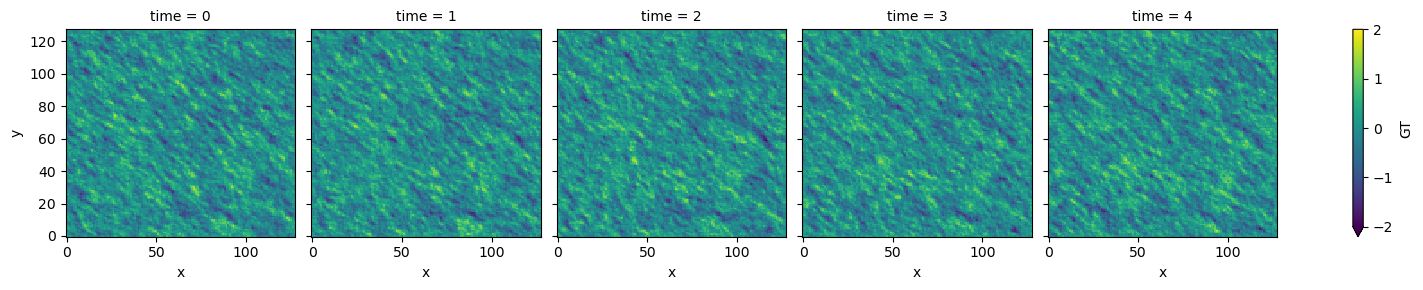

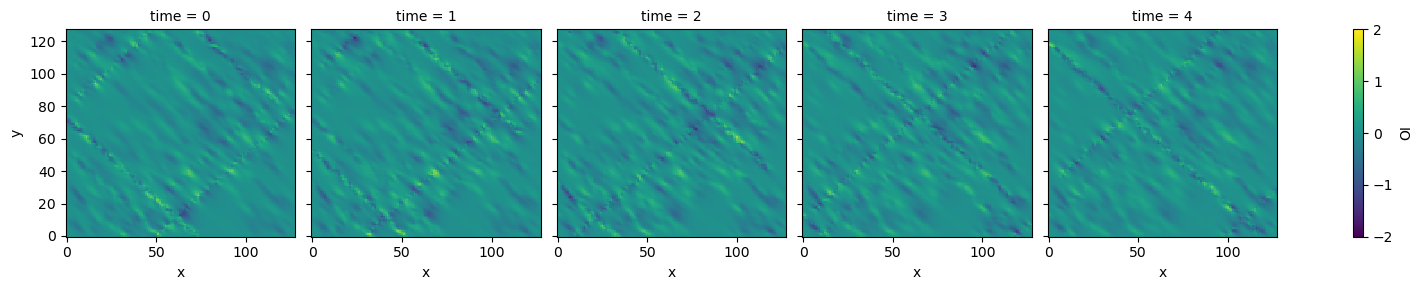

In [27]:
import xarray as xr
# ground truth along the DAW
gt = x[np.arange(target_time-2,target_time+3)].reshape(nt,nx,ny).cpu().numpy()
# optiml interpolation
out = x_estim
# store outputs as xarray datasets
ds = xr.Dataset(
            data_vars={
                'GT': (('time', 'y', 'x'), np.transpose(gt,(0,2,1))),
                'OI': (('time', 'y', 'x'), np.transpose(out,(0,2,1))),
            },
            coords={
                'time': range(nt),
                'y': range(ny),
                'x': range(nx),
            }
        )
ds.GT.plot(col='time',vmin=-2,vmax=2)
ds.OI.plot(col='time',vmin=-2,vmax=2)
plt.show()

# 4. Spatio-temporal conditional simulations

Because OI acts by construction as a smoother of the hidden truth, an option to retrieve the original variability of the gaussian process is to run simulations conditionned by kriging. A simple though elegant solution in traditional geostatistics is to propose a conditional simulation $\mathbf{x}_x$ to be equal to:
\begin{align*}
 \mathbf{x}_c (\mathbf{s}) = \mathbf{x}^\star(\mathbf{s}) + (\mathbf{x}_{nc}(\mathbf{s}) - \mathbf{x}^\star_{nc}(\mathbf{s}))
\end{align*}

## 4.1 Run an alternate simulation

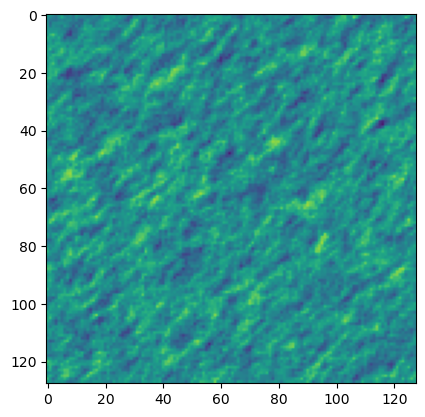

In [28]:
# Initialisation  
x2 = [torch.randn(nb_nodes)]
for i in range(n_iter):
    x2 = run_simulation(i,x2)
x2 = torch.stack(x2[1:],dim=0)

## 4.2 Extract this new simulation at the observation points

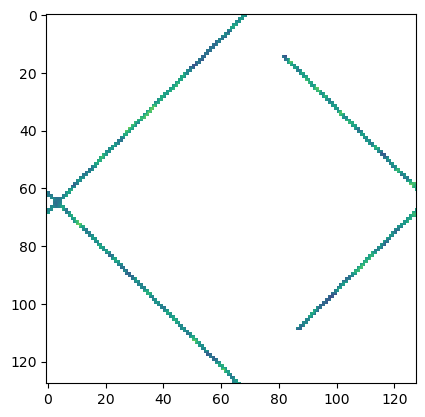

In [29]:
y2 = torch.empty(x2.shape)
y2[:] = np.nan
for i in range(n_iter):
  plt.cla()
  y2, _ = generate_pseudo_obs(i,x,y)

## 4.3 Kriging of the simulation

In [30]:
target_time = 50
x_estim_simulation = space_time_kriging(Qg,target_time,index_obs,y2).reshape(nt,nx,ny).cpu().numpy()

/tmp/ipykernel_1924725/824758003.py:8: VisibleDeprecationWarning: This function is deprecated and will be removed in a future release. Use the cupy.from_dlpack() array constructor instead.
  val = cupy.fromDlpack(to_dlpack(A.coalesce().values().data))
/tmp/ipykernel_1924725/824758003.py:9: VisibleDeprecationWarning: This function is deprecated and will be removed in a future release. Use the cupy.from_dlpack() array constructor instead.
  ind = cupy.fromDlpack(to_dlpack(A.coalesce().indices().data))
/tmp/ipykernel_1924725/824758003.py:11: VisibleDeprecationWarning: This function is deprecated and will be removed in a future release. Use the cupy.from_dlpack() array constructor instead.
  b_ = cupy.fromDlpack(to_dlpack(b))
/tmp/ipykernel_1924725/824758003.py:14: VisibleDeprecationWarning: This function is deprecated and will be removed in a future release. Use the cupy.from_dlpack() array constructor instead.
  x = from_dlpack(x_.toDlpack()).to(device)
/tmp/ipykernel_1924725/824758003.p

## 4.4 Conditional simulation 

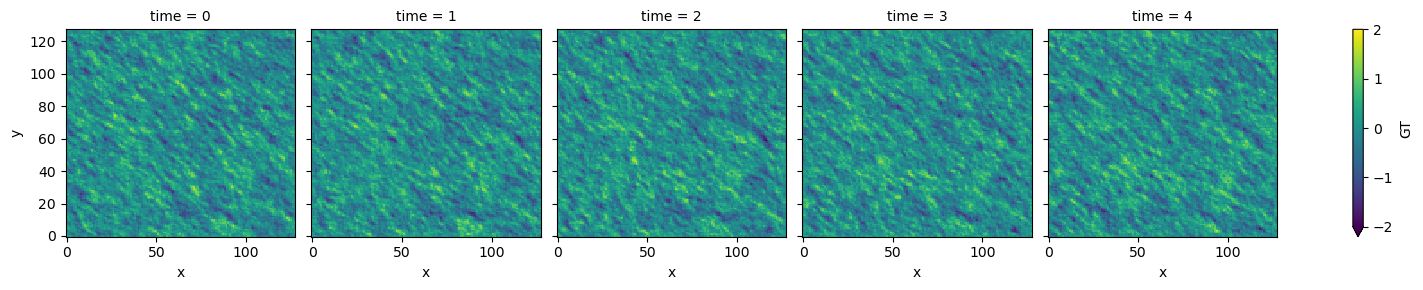

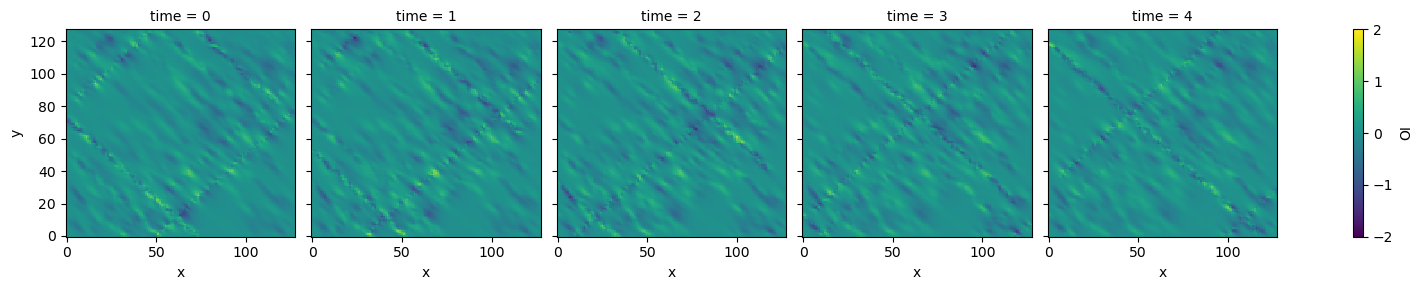

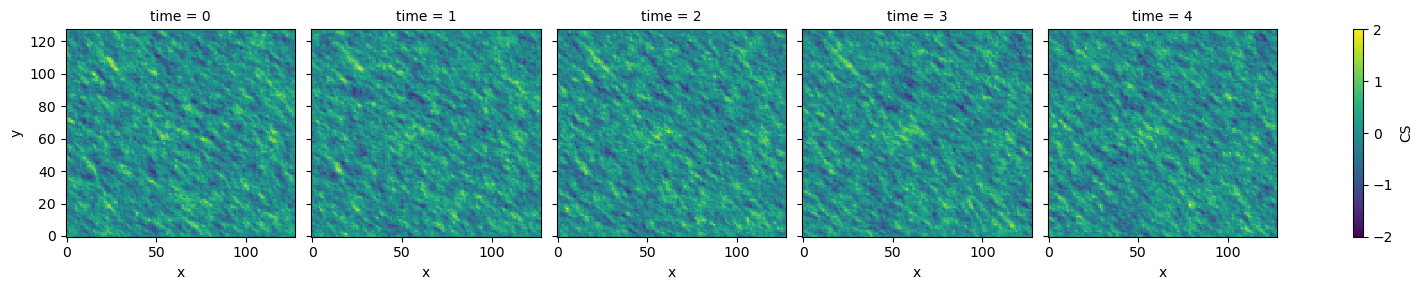

In [31]:
simulation = x2[np.arange(target_time-2,target_time+3)].reshape(nt,nx,ny).cpu().numpy()
x_cs = x_estim + (simulation-x_estim_simulation)
ds = ds.update({ 'CS': (('time', 'y', 'x'),x_cs)})
ds.GT.plot(col='time',vmin=-2,vmax=2)
ds.OI.plot(col='time',vmin=-2,vmax=2)
ds.CS.plot(col='time',vmin=-2,vmax=2)
plt.show()

# 5. Same framework with local anisotropy

Let now introduce some local anisotropies. The underlying idea in this practical session would be to generate some artifical eddies.

\begin{eqnarray*}
(\kappa^2-\nabla \cdot \mathbf{H}(\mathbf{s},t)\nabla)^{\frac{\alpha}{2}}\mathbf{X}(\mathbf{s},t)=\tau\mathbf{Z}(\mathbf{s},t)
\end{eqnarray*}

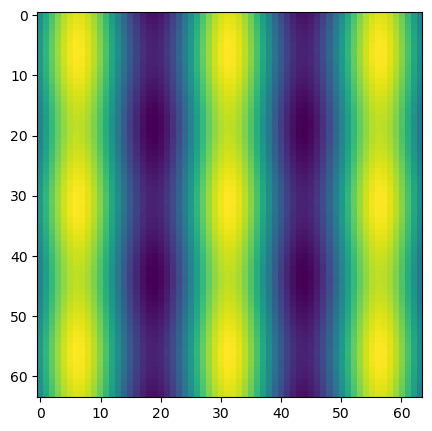

In [4]:
plt.rcParams['figure.figsize'] = [10,5]

def fxy(x,y):
 return( ((2*resolution)/np.pi)*( (3/4)*np.sin(2*np.pi*x/(5*resolution))) + (1/4)*np.sin(2*np.pi*y/(5*resolution) ))

x, y = np.meshgrid(range(nx),range(ny))
res = np.array(fxy(x,y))

plt.imshow(res)
grad = np.gradient(res)
u_ = grad[0]
v_ = grad[1]

def rotate_vector(x1,y1,angle):
  x1_ = x1.flatten()
  y1_ = y1.flatten()
  x2_ = np.cos(angle)*x1_-np.sin(angle)*y1_
  y2_ = np.sin(angle)*x1_+np.cos(angle)*y1_
  return np.c_[x2_,y2_]

u = np.transpose(np.reshape(np.array(rotate_vector(u_,v_,-np.pi/2)[:,0],),(nx,ny)))
v = np.transpose(np.reshape(np.array(rotate_vector(u_,v_,-np.pi/2)[:,1]),(nx,ny)))
plt.show()

In [5]:
def diffusion_tensor(u,v,gamma,beta):
  nb_nodes = u.shape[0]*u.shape[1]
  H = np.zeros((2,2,nb_nodes))
  cpt=0
  for i in range(u.shape[0]):
    for j in range(u.shape[1]):
      vs = np.r_[u[i,j],v[i,j]].reshape((2,1))
      Hs = (gamma*np.eye(2)) + beta*(vs @ vs.T)
      H[:,:,cpt] = Hs
      cpt = cpt+1
  return H

H_ = torch.from_numpy(diffusion_tensor(u,v,1,25)).float()

\begin{eqnarray}
H(\mathbf{s})=\gamma \mathbf{I}_2 + \beta\left[\mathbf{v}(\mathbf{s}) \mathbf{v}(\mathbf{s})^\mathrm{T}\right]
\end{eqnarray}

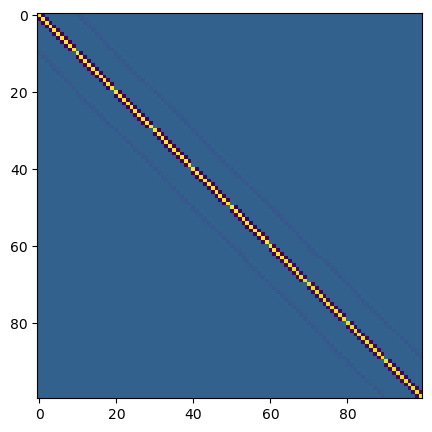

In [8]:
%matplotlib inline

def diff_operator2(nx, ny, dx, dy, H, kappa):

    nb_nodes = nx*ny

    index = torch.arange(0,nb_nodes)
    ## Right neighbours
    index_sel = torch.where(torch.fmod(index+1,nx) != 0)[0]
    N=len(index_sel)
    index_sel_neighs = torch.index_select(index,0,index_sel)
    k1 = torch.stack((index_sel_neighs.float(), index_sel_neighs.float() + 1, (-1*H[0,0,index_sel_neighs]/(dx**2)) ))
    ## Left neighbours
    index_sel = torch.where(torch.fmod(index+1,nx) != 1)[0]
    N=len(index_sel)
    index_sel_neighs = torch.index_select(index,0,index_sel)
    k2 = torch.stack((index_sel_neighs.float(), index_sel_neighs.float() - 1, (-1*H[0,0,index_sel_neighs]/(dx**2)) ))
    ## Top neighbours
    index_sel = torch.where((index+1) <= (ny-1)*nx )[0]
    N=len(index_sel)
    index_sel_neighs = torch.index_select(index,0,index_sel)
    k3 = torch.stack((index_sel_neighs.float(), index_sel_neighs.float() + nx, (-1*H[1,1,index_sel_neighs]/(dx**2)) ))
    ## Bottom neighbours
    index_sel = torch.where((index+1) >= (nx+1) )[0]
    N=len(index_sel)
    index_sel_neighs = torch.index_select(index,0,index_sel)
    k4 = torch.stack((index_sel_neighs.float(), index_sel_neighs.float() - nx, (-1*H[1,1,index_sel_neighs]/(dx**2)) ))
    ## Top-right neighbours
    index_sel = torch.where( (torch.fmod(index+1,nx) != 0) & ((index+1)<= (ny-1)*nx) )[0]
    N=len(index_sel)
    index_sel_neighs = torch.index_select(index,0,index_sel)
    k5 = torch.stack((index_sel_neighs.float(), index_sel_neighs.float() + nx+1, ((H[0,1,index_sel_neighs]+H[1,0,index_sel_neighs])/(4*dx*dy)) ))
    ## Top-left neighbours
    index_sel = torch.where( (torch.fmod(index+1,nx) != 1) & ((index+1)<= (ny-1)*nx) )[0]
    N=len(index_sel)
    index_sel_neighs = torch.index_select(index,0,index_sel)
    k6 = torch.stack((index_sel_neighs.float(), index_sel_neighs.float() + nx-1, (-1*(H[0,1,index_sel_neighs]+H[1,0,index_sel_neighs])/(4*dx*dy)) ))
    ## Bottom-right neighbours
    index_sel = torch.where( (torch.fmod(index+1,nx) != 0) & ((index+1)>=(nx+1)) )[0]
    N=len(index_sel)
    index_sel_neighs = torch.index_select(index,0,index_sel)
    k7 = torch.stack((index_sel_neighs.float(), index_sel_neighs.float() - nx+1, (-1*(H[0,1,index_sel_neighs]+H[1,0,index_sel_neighs])/(4*dx*dy)) ))
    ## Bottom-left neighbours
    index_sel = torch.where( (torch.fmod(index+1,nx) != 1) & ((index+1)>=(nx+1)) )[0]
    N=len(index_sel)
    index_sel_neighs = torch.index_select(index,0,index_sel)
    k8 = torch.stack((index_sel_neighs.float(), index_sel_neighs.float() - nx-1, ((H[0,1,index_sel_neighs]+H[1,0,index_sel_neighs])/(4*dx*dy)) ))
    ## Central point
    N=len(index)
    k9 = torch.stack((index.float(), index.float(), (kappa**2 + 2*(H[0,0,index]/(dx**2) + H[1,1,index]/(dy**2))) ))
    ## Stack all neighbours
    k = torch.cat((k1, k2, k3, k4, k5, k6, k7, k8, k9),dim=1)
    ## Create sparseMatrix
    return(torch.sparse.FloatTensor(k[0:2].long(), k[2], torch.Size([nb_nodes,nb_nodes])))

## Example
A=diff_operator2(10,10,1,1,H=H_,kappa=1/3)
plt.imshow(A.to_dense().numpy())

In [9]:
%matplotlib inline

pow=1.
A=diff_operator2(nx,ny,dx,dy,H=H_,kappa=1./3)
B=pow_diff_operator(A,pow)
L = Scipy_SolveCholesky.apply(B,dt)
Achol = torch.tensor(np.dot(L.to_dense().numpy(),np.transpose(L.to_dense().numpy())))

/tmp/ipykernel_2150125/3836502537.py:49: UserWarning: torch.sparse.SparseTensor(indices, values, *, device=) is deprecated.  Please use torch.sparse_coo_tensor(indices, values, dtype=, device=). (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:641.)
  L = torch.sparse.FloatTensor(torch.LongTensor([Lcoo.row.tolist(), Lcoo.col.tolist()]),


In [36]:
# Initialisation  
x = [torch.randn(nb_nodes)]

filenames = []
for i in range(n_iter):
    plt.cla()
    x = run_simulation(i,x)
    filename = f'{i}.png'
    filenames.append(filename)
    # save frame
    plt.savefig(filename)
    plt.close()
    
# build gif
if os.path.exists('mysimu2.gif'):
    os.remove('mysimu2.gif')
with imageio.get_writer('mysimu2.gif', mode='I') as writer:
    for filename in filenames:
        image = imageio.imread(filename)
        writer.append_data(image)
        
# Remove files
for filename in set(filenames):
    os.remove(filename)
    
x = torch.stack(x[1:],dim=0)

/tmp/ipykernel_1924725/1213709184.py:19: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image = imageio.imread(filename)


In [37]:
from IPython.display import Image
Image(url='mysimu2.gif') 

In [38]:
y = torch.empty(x.shape)
y[:] = np.nan
index_obs = []

for i in range(n_iter):
  plt.cla()
  y, index_obs = generate_pseudo_obs(i,x,y)
  filename = f'{i}.png'
  filenames.append(filename)
  # save frame
  plt.savefig(filename)
  plt.close()

# build gif
if os.path.exists('mydata2.gif'):
    os.remove('mydata2.gif')
with imageio.get_writer('mydata2.gif', mode='I') as writer:
    for filename in filenames:
        image = imageio.imread(filename)
        writer.append_data(image)
        
# Remove files
for filename in set(filenames):
    os.remove(filename)

/tmp/ipykernel_1924725/2776820694.py:19: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image = imageio.imread(filename)


In [39]:
from IPython.display import Image
Image(url='mydata2.gif') 

/tmp/ipykernel_1924725/824758003.py:8: VisibleDeprecationWarning: This function is deprecated and will be removed in a future release. Use the cupy.from_dlpack() array constructor instead.
  val = cupy.fromDlpack(to_dlpack(A.coalesce().values().data))
/tmp/ipykernel_1924725/824758003.py:9: VisibleDeprecationWarning: This function is deprecated and will be removed in a future release. Use the cupy.from_dlpack() array constructor instead.
  ind = cupy.fromDlpack(to_dlpack(A.coalesce().indices().data))
/tmp/ipykernel_1924725/824758003.py:11: VisibleDeprecationWarning: This function is deprecated and will be removed in a future release. Use the cupy.from_dlpack() array constructor instead.
  b_ = cupy.fromDlpack(to_dlpack(b))
/tmp/ipykernel_1924725/824758003.py:14: VisibleDeprecationWarning: This function is deprecated and will be removed in a future release. Use the cupy.from_dlpack() array constructor instead.
  x = from_dlpack(x_.toDlpack()).to(device)
/tmp/ipykernel_1924725/824758003.p

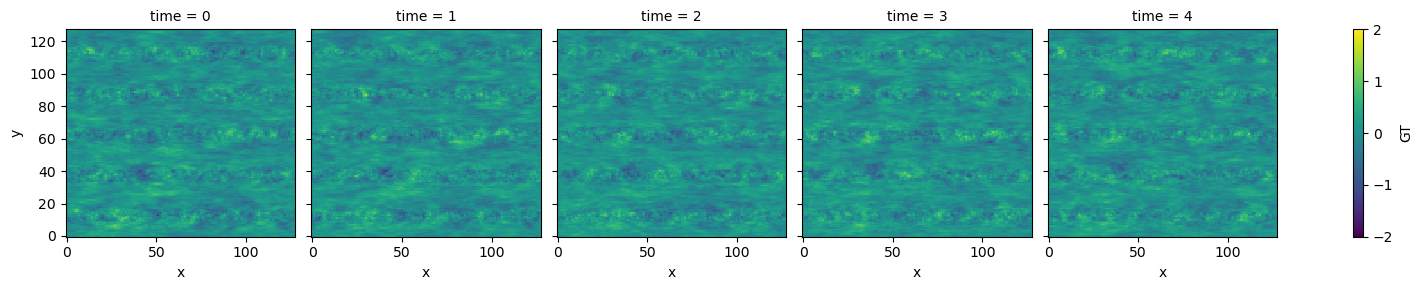

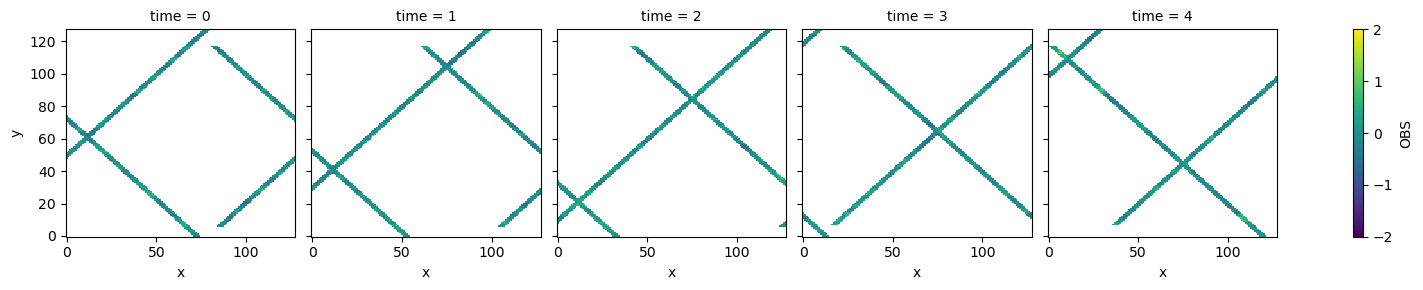

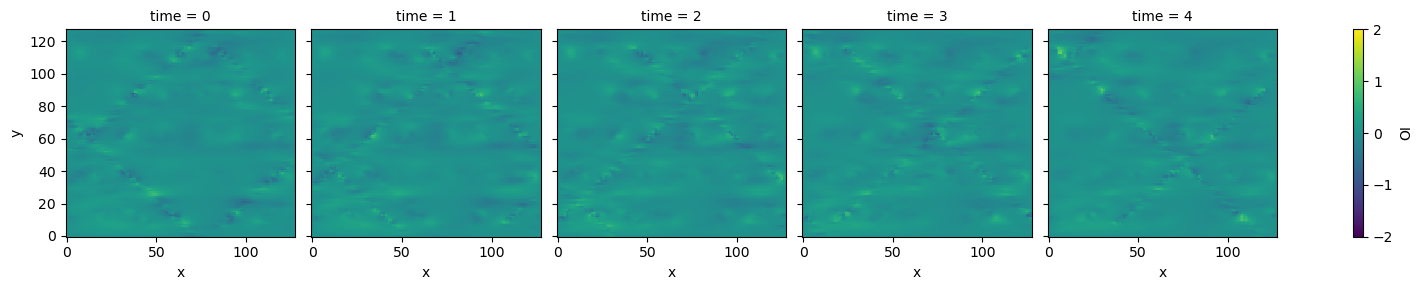

In [40]:
Qg = global_precision_matrix(B)
target_time = 50
x_estim = space_time_kriging(Qg,target_time,index_obs,x).reshape(nt,nx,ny).cpu().numpy()
gt = x[np.arange(target_time-2,target_time+3)].reshape(nt,nx,ny).cpu().numpy()
obs = y[np.arange(target_time-2,target_time+3)].reshape(nt,nx,ny).cpu().numpy()
ds = xr.Dataset(
            data_vars={
                'GT': (('time', 'y', 'x'), gt),
                'OBS': (('time', 'y', 'x'), obs),
                'OI': (('time', 'y', 'x'), x_estim),
            },
            coords={
                'time': range(nt),
                'y': range(ny),
                'x': range(nx),
            }
        )
ds.GT.plot(col='time',vmin=-2,vmax=2)
ds.OBS.plot(col='time',vmin=-2,vmax=2)
ds.OI.plot(col='time',vmin=-2,vmax=2)
plt.show()

/tmp/ipykernel_1924725/824758003.py:8: VisibleDeprecationWarning: This function is deprecated and will be removed in a future release. Use the cupy.from_dlpack() array constructor instead.
  val = cupy.fromDlpack(to_dlpack(A.coalesce().values().data))
/tmp/ipykernel_1924725/824758003.py:9: VisibleDeprecationWarning: This function is deprecated and will be removed in a future release. Use the cupy.from_dlpack() array constructor instead.
  ind = cupy.fromDlpack(to_dlpack(A.coalesce().indices().data))
/tmp/ipykernel_1924725/824758003.py:11: VisibleDeprecationWarning: This function is deprecated and will be removed in a future release. Use the cupy.from_dlpack() array constructor instead.
  b_ = cupy.fromDlpack(to_dlpack(b))
/tmp/ipykernel_1924725/824758003.py:14: VisibleDeprecationWarning: This function is deprecated and will be removed in a future release. Use the cupy.from_dlpack() array constructor instead.
  x = from_dlpack(x_.toDlpack()).to(device)
/tmp/ipykernel_1924725/824758003.p

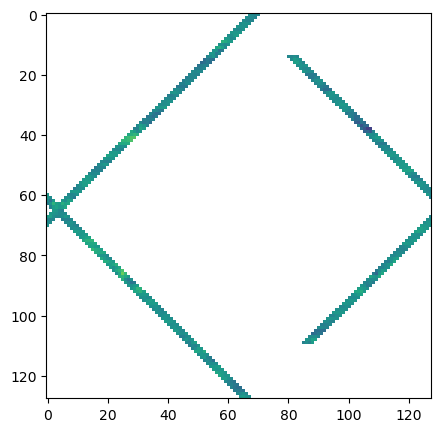

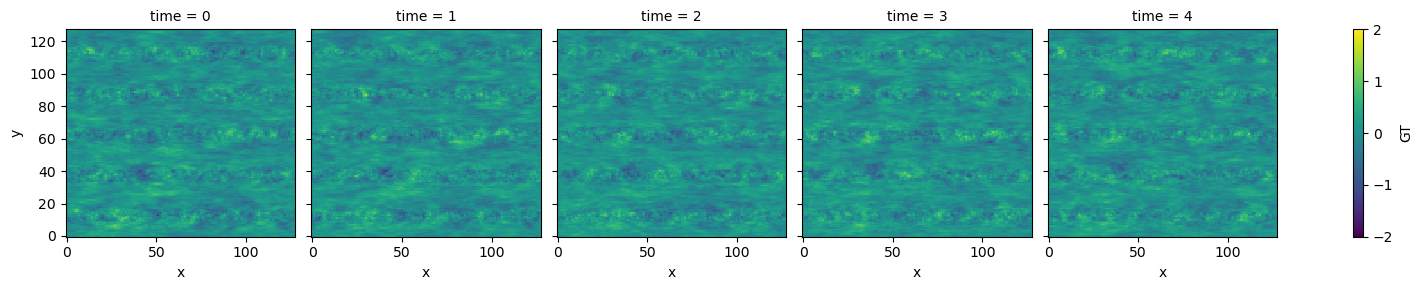

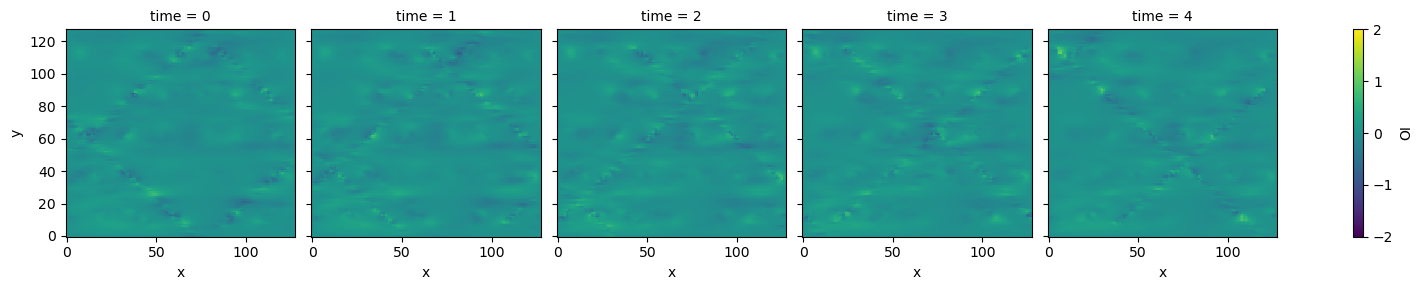

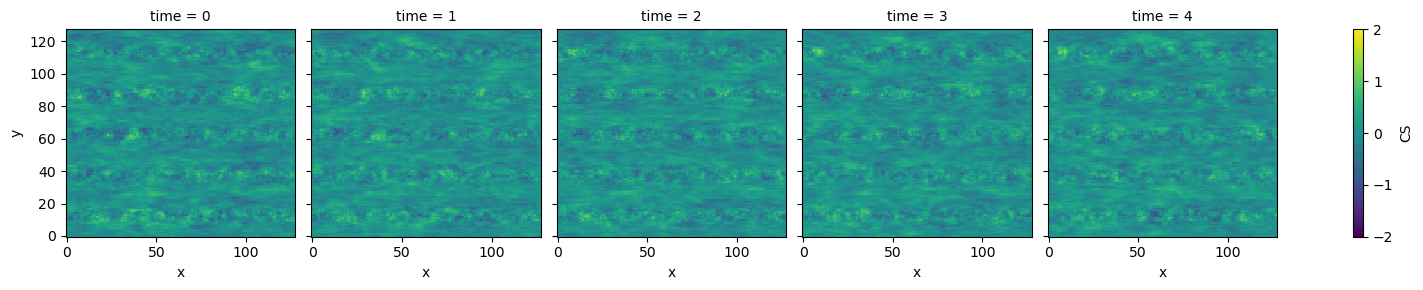

In [ ]:
# New simulation
x2 = [torch.randn(nb_nodes)]
for i in range(n_iter):
    x2 = run_simulation(i,x2)
x2 = torch.stack(x2[1:],dim=0)
# Extract simulation at observation points
y2 = torch.empty(x2.shape)
y2[:] = np.nan
for i in range(n_iter):
  plt.cla()
  y2, _ = generate_pseudo_obs(i,x2,y2)
# Kriging of the simulation
target_time = 50
x_estim_simulation = space_time_kriging(Qg,target_time,index_obs,y2).reshape(nt,nx,ny).cpu().numpy()
# Conditional simulation
simulation = x2[np.arange(target_time-2,target_time+3)].reshape(nt,nx,ny).cpu().numpy()
x_cs = x_estim + (simulation-x_estim_simulation)
ds = ds.update({ 'CS': (('time', 'y', 'x'),x_cs)})
ds.GT.plot(col='time',vmin=-2,vmax=2)
ds.OI.plot(col='time',vmin=-2,vmax=2)
ds.CS.plot(col='time',vmin=-2,vmax=2)
plt.show()

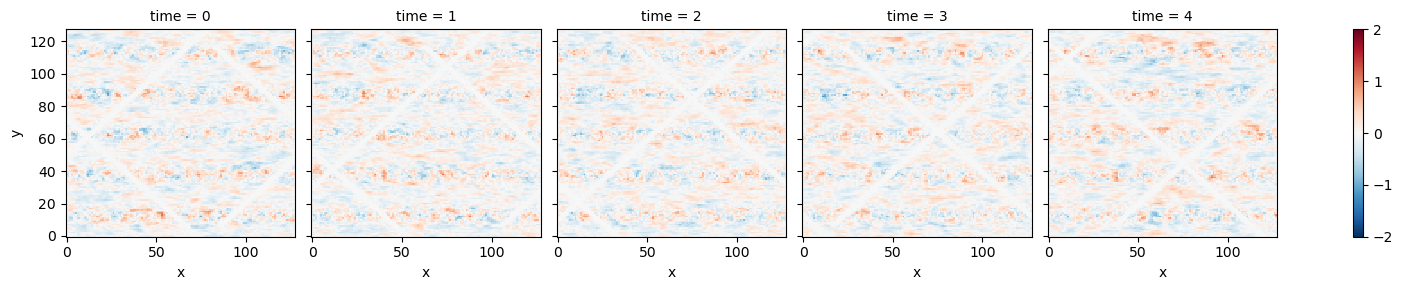

In [44]:
(ds.CS -ds.OI).plot(col='time',vmin=-2,vmax=2,cmap='RdBu_r')


# 6. Run the OI baseline

Here, let run the OI baseline on the entire dataset, from $t$=0 to $t$=500. Then, let start by generating a new simulation with 500 time step and additional pseudo-obs before running the associated oi

In [ ]:
# new simulation with n_iter = 500
n_iter = 500
x = [torch.randn(nb_nodes)]
for i in range(n_iter):
    x = run_simulation(i,x)
x = torch.stack(x[1:],dim=0)
# Extract simulation at observation points
y = torch.empty(x.shape)
y[:] = np.nan
index_obs = []
for i in range(n_iter):
  plt.cla()
  y, index_obs = generate_pseudo_obs(i,x,y)
# run the oi
oi = np.empty((n_iter,nx,ny))
for i in range(n_iter):
    print(i)
    if ( (i>=2) and (i<n_iter-2) ):
        oi[i] = space_time_kriging(Qg,i,index_obs,y).reshape(nt,nx,ny).cpu().numpy()[int(nt/2)]

0
1
2


/tmp/ipykernel_1924725/824758003.py:8: VisibleDeprecationWarning: This function is deprecated and will be removed in a future release. Use the cupy.from_dlpack() array constructor instead.
  val = cupy.fromDlpack(to_dlpack(A.coalesce().values().data))
/tmp/ipykernel_1924725/824758003.py:9: VisibleDeprecationWarning: This function is deprecated and will be removed in a future release. Use the cupy.from_dlpack() array constructor instead.
  ind = cupy.fromDlpack(to_dlpack(A.coalesce().indices().data))
/tmp/ipykernel_1924725/824758003.py:11: VisibleDeprecationWarning: This function is deprecated and will be removed in a future release. Use the cupy.from_dlpack() array constructor instead.
  b_ = cupy.fromDlpack(to_dlpack(b))
/dmidata/users/maxb/conda/envs/4dvarnet-starter/lib/python3.12/site-packages/cupyx/scipy/sparse/linalg/_solve.py:517: SparseEfficiencyWarning: CSR format is required. Converting to CSR format.
  warnings.warn('CSR format is required. Converting to CSR format.',
/tmp/i

3
4
4
5
5
6
6
7
7
8
8
9
9
10
10
11
11
12
12
13
13
14
14
15
15
16
16
17
17
18
18
19
19
20
20
21
21
22
22
23
23
24
24
25
25


# 7. Save the dataset

In [40]:
ds = xr.Dataset(
    data_vars=dict(
        x = (["time", "lat", "lon"], x.reshape((n_iter,nx,ny))),
        y = (["time", "lat", "lon"], y.reshape((n_iter,nx,ny))),
        OI = (["time", "lat", "lon"], oi),
        H11 = (["lat", "lon"], H_[0,0,:].reshape(nx,ny)),
        H22 = (["lat", "lon"], H_[1,1,:].reshape(nx,ny)),
        H12 = (["lat", "lon"], H_[0,1,:].reshape(nx,ny)),
        Time = (["time"], np.arange(n_iter)),
        longitude = (["lon"], np.arange(0,nx)),
        latitude = (["lat"], np.arange(0,ny))
    ),
    coords=dict(
        lon = np.arange(0,nx),
        lat = np.arange(0,ny),
        time = np.arange(n_iter)
    ),
    attrs=dict(description="SPDE-based diffusion GP"),
)

In [41]:
ds

<xarray.Dataset> Size: 3MB
Dimensions:    (time: 15, lat: 100, lon: 100)
Coordinates:
  * lon        (lon) int64 800B 0 1 2 3 4 5 6 7 8 ... 91 92 93 94 95 96 97 98 99
  * lat        (lat) int64 800B 0 1 2 3 4 5 6 7 8 ... 91 92 93 94 95 96 97 98 99
  * time       (time) int64 120B 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14
Data variables:
    x          (time, lat, lon) float32 600kB -0.05436 -0.1566 ... -0.02551
    y          (time, lat, lon) float32 600kB nan nan nan nan ... nan nan nan
    OI         (time, lat, lon) float64 1MB 4.684e-310 4.684e-310 ... nan nan
    H11        (lat, lon) float32 40kB 9.953 9.953 9.953 ... 9.673 9.673 9.673
    H22        (lat, lon) float32 40kB 1.025 1.024 1.023 ... 1.021 1.023 1.024
    H12        (lat, lon) float32 40kB -0.4688 -0.4651 ... -0.4469 -0.4541
    Time       (time) int64 120B 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14
    longitude  (lon) int64 800B 0 1 2 3 4 5 6 7 8 ... 91 92 93 94 95 96 97 98 99
    latitude   (lat) int64 800B 0 1 2 3 4 5 6 7 8 ... 91 92 93 94 95 96 97 98 99
Attributes:
    description:  SPDE-based diffusion GP

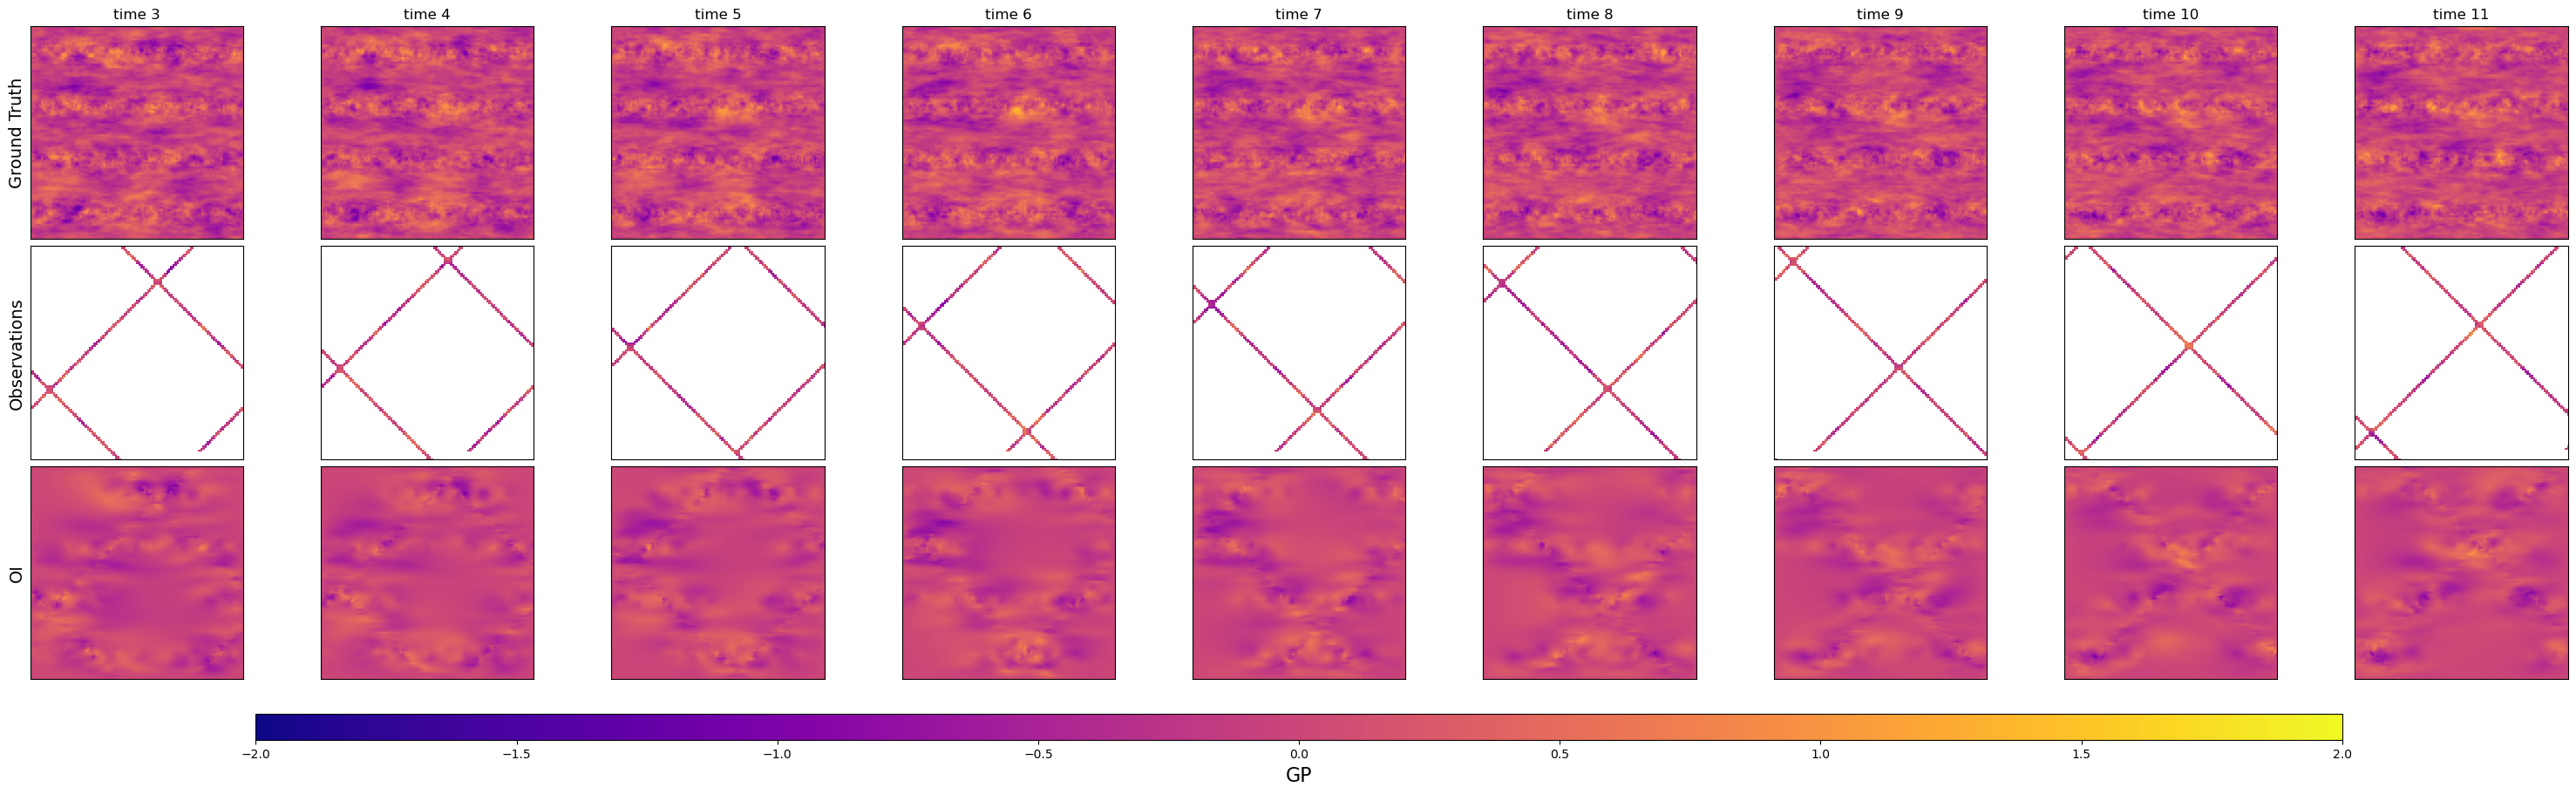

In [52]:
# Combine ds.x, ds.y, and ds.OI into a single plot with one colorbar
fig, axes = plt.subplots(3, 9, figsize=(30, 9), constrained_layout=True)

time_slice = slice(3, 12)
data_x = ds.x.isel(time=time_slice)
data_y = ds.y.isel(time=time_slice)
data_oi = ds.OI.isel(time=time_slice)

# Row 0: Ground Truth (x)
for time_idx in range(9):
    ax = axes[0, time_idx]
    im = ax.imshow(data_x[time_idx].values, vmin=-2, vmax=2, cmap=plt.cm.plasma)
    ax.set_xticks([])
    ax.set_yticks([])
    if time_idx == 0:
        ax.set_ylabel('Ground Truth', fontsize=14)
    ax.set_title(f'time {time_idx + 3}', fontsize=12)

# Row 1: Observations (y)
for time_idx in range(9):
    ax = axes[1, time_idx]
    im = ax.imshow(data_y[time_idx].values, vmin=-2, vmax=2, cmap=plt.cm.plasma)
    ax.set_xticks([])
    ax.set_yticks([])
    if time_idx == 0:
        ax.set_ylabel('Observations', fontsize=14)

# Row 2: OI
for time_idx in range(9):
    ax = axes[2, time_idx]
    im = ax.imshow(data_oi[time_idx].values, vmin=-2, vmax=2, cmap=plt.cm.plasma)
    ax.set_xticks([])
    ax.set_yticks([])
    if time_idx == 0:
        ax.set_ylabel('OI', fontsize=14)

# Add a single colorbar below all subplots
cbar = fig.colorbar(im, ax=axes, orientation='horizontal', fraction=0.05, pad=0.05, aspect=80, shrink=0.8)
cbar.set_label('GP', fontsize=16)

plt.savefig("../../../4dvarnet-starter/figs/combined_plot_gp_data_Notebook.png", dpi=300, bbox_inches='tight')
plt.show()

In [44]:
ds.to_netcdf('SPDE_diffusion_dataset.nc')

# Connection with diffusion models

In [10]:
import torch
import matplotlib.pyplot as plt
import imageio
import os

torch.set_default_dtype(torch.float32)

# -------------------------
# Paramètres
# -------------------------
nsteps = 10
nbNodes = nx*ny
dt = 0.1
sigma = 0.3

# Identity matrix
Id = sparse_eye(nbNodes)
Id_dense = torch.eye(nbNodes).float()

# -------------------------
# Stockage
# -------------------------
Z_all = [torch.randn(nbNodes,1)]
P_all = [torch.eye(nbNodes).float()]
M_all = []
T_all = []
F_all = []

# -------------------------
# Fonction de simulation
# -------------------------
def run_simulation(i):

    # --- opérateur de diffusion ---
    A = diff_operator2(nx,ny,dx,dy,H_,0.33)
    B = spspmm(A,A)
    B = 0.5*(B + B.t()).float()

    # --- matrice de transition implicite ---
    M = torch.linalg.inv((Id + dt*B).to_dense()).float()

    # --- bruit ---
    z = torch.randn(nbNodes,1)
    RM = sigma * torch.sqrt(torch.tensor(dt/(dx*dy))) * z
    RM = RM + Z_all[i]
    # --- résolveur Cholesky implicite ---
    L = Scipy_SolveCholesky.apply(Id + dt*B, dt)
    L_dense = torch.tril(L.to_dense()).float()

    Z = torch.linalg.solve_triangular(L_dense, RM, upper=False)
    Z = torch.linalg.solve_triangular(L_dense.T, Z, upper=True)

    # --- matrice de diffusion ---
    T = M @ (sigma*Id_dense)

    # --- propagation de la covariance ---
    P = M @ P_all[i] @ M.T + T @ T.T

    # --- stockage ---
    Z_all.append(Z)
    P_all.append(P)
    M_all.append(M)
    T_all.append(T)
    F_all.append(B)

    # --- affichage ---
    plt.imshow(Z.detach().numpy().reshape(nx,ny), vmin=-2, vmax=2)

In [11]:
filenames = []

for i in range(nsteps):
    print(i)
    plt.cla()
    run_simulation(i)
    filename = f"frame_{i}.png"
    filenames.append(filename)
    plt.savefig(filename)
    plt.close()

# Génération GIF
with imageio.get_writer("forward_simulation.gif", mode="I") as writer:
    for f in filenames:
        writer.append_data(imageio.imread(f))

for f in filenames:
    os.remove(f)

0


/dmidata/users/maxb/conda/envs/4dvarnet-starter/lib/python3.12/site-packages/torch_sparse/matmul.py:97: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at /pytorch/aten/src/ATen/SparseCsrTensorImpl.cpp:53.)
  C = torch.sparse.mm(A, B)


1
2
2
3
3
4
4
5
5
6
6
7
7
8
8
9
9


/tmp/ipykernel_2150125/773634301.py:15: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  writer.append_data(imageio.imread(f))


In [12]:
Z_all = torch.stack(Z_all, dim=0)
P_all = torch.stack(P_all, dim=0)


In [13]:
import xarray as xr
data = xr.Dataset(coords={'lon':np.arange(64),'lat':np.arange(64),'time':np.arange(Z_all.shape[0])},
                  data_vars={'gp':(('time','lat','lon'),np.reshape(Z_all.numpy(),(Z_all.shape[0],64,64)))})

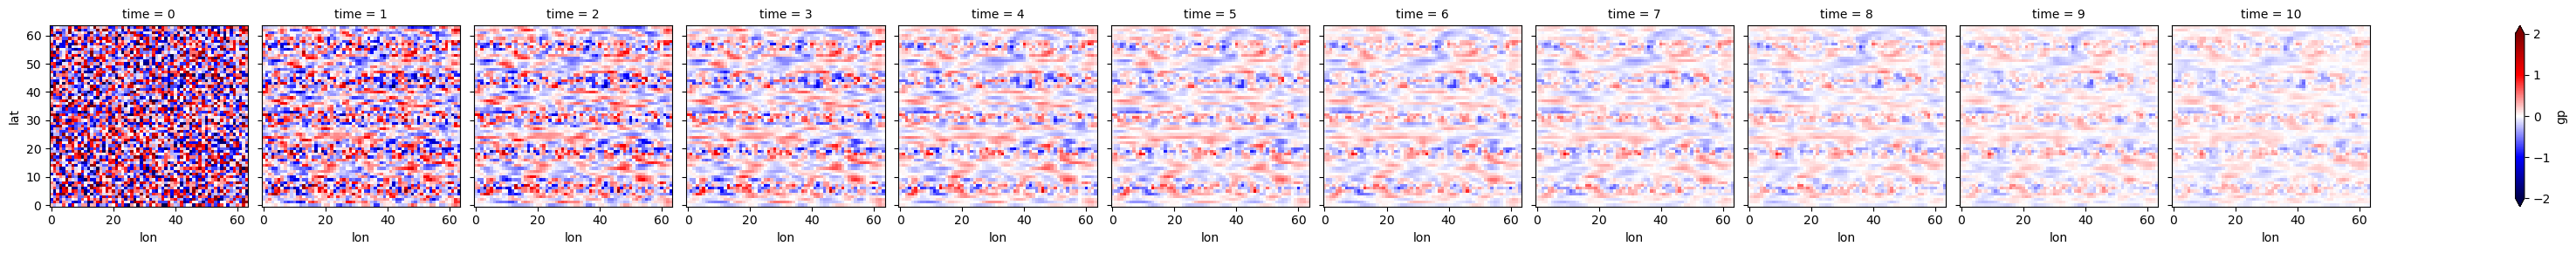

In [14]:
data.gp.plot(col='time',col_wrap=nsteps+1,vmin=-2,vmax=2, cmap=plt.cm.seismic)

In [15]:
# -------------------------
# Reverse process
# -------------------------

def reverse_step(xt, Mt, Tt, Pt):

    xt = xt.reshape(nbNodes,1)

    z = torch.randn(nbNodes,1)

    score = -torch.linalg.solve(Pt, xt)

    drift = (Mt - Id) @ xt - 0.5 * (Tt @ Tt.T) @ score

    xt_prev = xt + drift + Tt @ z

    return xt_prev

nbSteps = nsteps

Z_all_rev = [Z_all[-1]]

xt = Z_all[-1].reshape(nbNodes,1)

for i in range(nsteps,0,-1):
    print(i)
    Mt = M_all[i-1]
    Tt = T_all[i-1]
    Pt = P_all[i]

    xt = reverse_step(xt,Mt,Tt,Pt)

    # stockage
    Z_all_rev.append(xt)

10
9
9
8
8
7
7
6
6
5
5
4
4
3
3
2
2
1
1


In [16]:
filenames = []

for i, Z in enumerate(Z_all_rev):
    plt.cla()
    plt.imshow(Z.detach().numpy().reshape(nx,ny), vmin=-2, vmax=2)
    filename = f"rev_{i}.png"
    filenames.append(filename)
    plt.savefig(filename)
    plt.close()

with imageio.get_writer("reverse_simulation.gif", mode="I") as writer:
    for f in filenames:
        image = imageio.imread(f)
        writer.append_data(image)

for f in filenames:
    os.remove(f)

/tmp/ipykernel_2150125/1527750936.py:13: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image = imageio.imread(f)


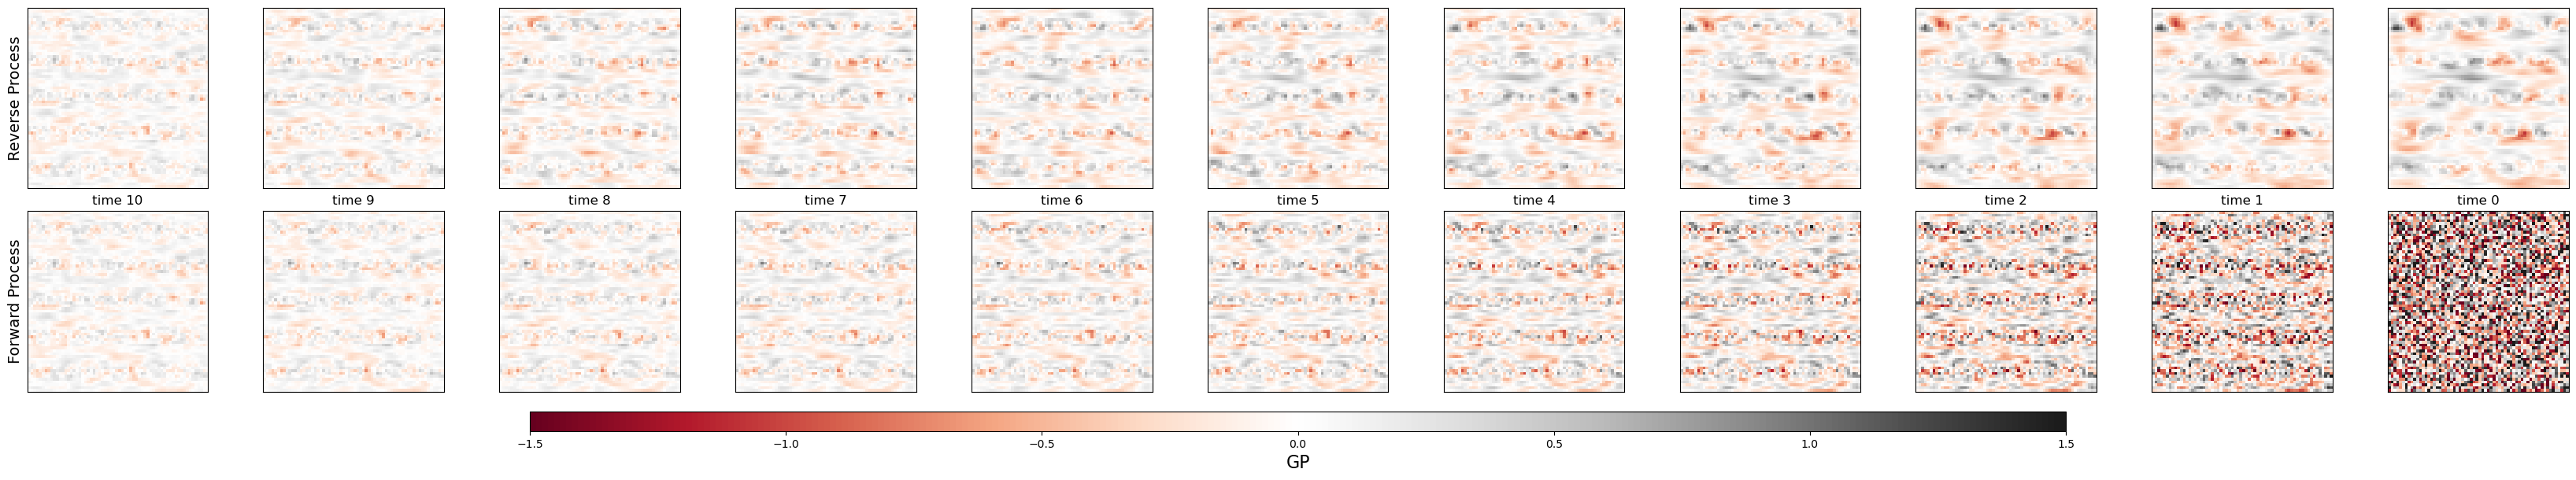

In [26]:
# Create combined plot for forward and reverse processes
fig, axes = plt.subplots(2, nsteps+1, figsize=(3*(nsteps+1), 6), constrained_layout=True)

# Reverse process (data_new)
for time_idx in range(nsteps+1):
    ax = axes[0, time_idx]
    im = ax.imshow(data_new.gp.isel(time=time_idx).values, vmin=-1.5, vmax=1.5, cmap=plt.cm.RdGy)
    ax.set_xticks([])
    ax.set_yticks([])
    if time_idx == 0:
        ax.set_ylabel('Reverse Process', fontsize=14)

# Forward process (data)
data_forward = data.reindex(time=list(reversed(data.time)))
for time_idx in range(nsteps+1):
    ax = axes[1, time_idx]
    im = ax.imshow(data_forward.gp.isel(time=time_idx).values, vmin=-1.5, vmax=1.5, cmap=plt.cm.RdGy)
    ax.set_xticks([])
    ax.set_yticks([])
    if time_idx == 0:
        ax.set_ylabel('Forward Process', fontsize=14)
    ax.set_title(f'time {nsteps - time_idx}', fontsize=12)

# Add a single colorbar below all subplots
cbar = fig.colorbar(im, ax=axes, orientation='horizontal', fraction=0.05, pad=0.05, aspect=80, shrink=0.8)
cbar.set_label('GP', fontsize=16)

plt.show()